In [2]:
# Building a linear regression from scratch to practice the mathematics involved

import numpy as np
import math 
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [3]:

#defining functions (linear, partials wrt beta_0 and beta_1)

def linear(m,x,b):      #simple linear function y=mx+b
    return m*x+b

def partial_m(m,y,x,b,n):       #unsummed partial of MSE with respect to slope
    return -2/n*np.sum(x*(y-(linear(m,x,b))))

def partial_b(m,y,x,b,n):       #unsummed partial of MSE with respect to bias
    return -2/n*np.sum((y-(linear(m,x,b))))

def noise(m, n, ratio):
    randoms = np.random.rand(n,)
    noise_level = m/ratio
    return randoms*noise_level

# for y=3x+2, noise should be something like +/- .5 i guess. thus, 1/6-ish of the slope is ok for noise...


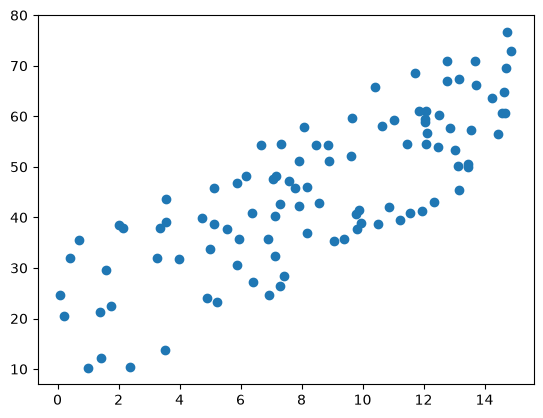

In [4]:
#creating slightly noisy linear data

numpoints = 100
slope = 3.14159
slope_noise = .1

x_points = np.random.uniform(low = 0, high = 15, size = (numpoints, ) )

y_points_line = linear(slope, x_points, 2)
y_noise = noise(slope, numpoints, slope_noise)

y_points = y_points_line + y_noise

df_dict = {"xpoints":x_points, "ypoints":y_points}

plt.scatter(x_points,y_points)
plt.show()


In [5]:
#importing our data as a dataframe

df = pd.DataFrame(data = df_dict)
print(df.head())
x_data = df.loc[:,'xpoints']
y_data = df.loc[:,'ypoints']

     xpoints    ypoints
0   7.293713  26.429537
1  14.689032  69.494710
2  11.036458  59.243678
3   6.188158  48.164865
4  10.860349  42.067579


In [13]:
#now, the actual algorithm for learning the dataset

epochs = 10000 
sl=0
bias=0
l = .001
nums = len(df)

for i in tqdm(range(epochs)):
    y = linear(sl,x_data,bias)
    m_new = sl - l*partial_m(sl, y_data, x_data, bias, nums)
    b_new = bias - l*partial_b(sl, y_data, x_data, bias, nums)

    sl = m_new
    bias = b_new


print(sl,bias)


100%|██████████| 10000/10000 [00:00<00:00, 10328.36it/s]

2.9007116602551335 20.42987348595062


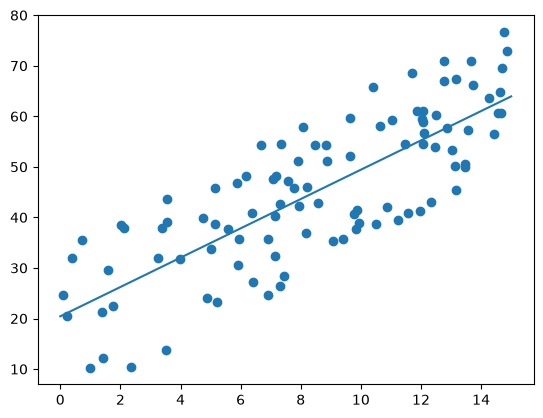

In [14]:
#plotting results

xstuff = np.linspace(0,15, num=nums)

plt.scatter(x_data, y_data)
plt.plot(xstuff, linear(sl,xstuff,bias))

plt.show()